# Code pour créer une figure qui contient, par exemple, une carte et un graphique (ou un barplot, un boxplot, quelque chose qui n'est pas une carte)


Version avancée du premier tuto_plot.ipynb.

Ici, on va utiliser le module **gridspec**.
Gridspec divise le plot en plusieurs cases (dont on peut fixer la hauteur et la largeur), c'est très pratique pour customiser ses plots.

On l'importe ainsi avec les autres modules:
import matplotlib.gridspec as gridspec


Dans ce code, on montre un exemple de son utilisation: on veut tracer une carte de concentrations et une moyenne zonale de cette variable (c'est assez courant surtout dans l'Austral où les patterns sont très latitudinaux pour la biologie, du moins dans CMIP6).

Voir la documentation et d'autres exemples ici: https://matplotlib.org/stable/api/_as_gen/matplotlib.gridspec.GridSpec.html

##### Written March 13, 2026

In [1]:
import numpy as np

# Modules pour lire les données netCDF
import netCDF4
from netCDF4 import Dataset
# module utile si tu as besoin d'interpoler des données
import xarray as xr

# Modules pour naviguer plus simplement dans les répertoires et lire les données
import os
from glob import glob

# Modules pour tracer des graphiques en Python

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

# CARTOPY = tracer des cartes
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# cmocean = colorbars adaptées pour données océano
import cmocean

/home/analivaev/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Lecture de données en entrée en utilisant le module netCDF4

In [2]:
rep_model='/home/analivaev/Documents/THESE/Data/CMIP6/historical/CHL/New_version/'
file_model='monmean_SO_chl_Omon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_199801-201412.nc'

data_model=Dataset(rep_model+file_model,'r',format='NETCDF4')

lon,lat=data_model.variables['lon'][:],data_model.variables['lat'][:]
chl=data_model.variables['chl'][:,:,:]


### Option: sélectionner les variables sur des longitudes, latitudes et mois spécifiques

In [6]:
# Southern Indian Ocean
lon_min=20
lon_max=120

ilon_min,ilon_max=np.searchsorted(lon[:],[lon_min,lon_max]) # voir tuto_plot pour np.searchsorted
lon_region=lon[ilon_min:ilon_max+1]

NDJ_months=[0,10,11] # index of January, November and December months

chl_NDJ_region=chl[NDJ_months,:,ilon_min:ilon_max+1]
# ce que veut dire la ligne de code ci-dessus:
#on sélectionne la chlorophylle sur les mois de Novembre à Janvier,
# et sur la région d'étude: l'océan Indien Sud, que l'on définit comme allant de 20°E (lon_min) à 120°E (lon_max).

In [7]:
print(np.shape(chl_NDJ_region))

(3, 60, 101)


In [8]:
# Ensuite on peut moyenner sur l'axe temps:
chl_NDJ_avg_region=np.nanmean(chl_NDJ_region,axis=0) # voir tuto_subplots pour np.nanmean
print(np.shape(chl_NDJ_avg_region))

(60, 101)


### Aparté: comment calculer et tracer une moyenne zonale:  pour chaque latitude, on moyenne sur toutes les longitudes de 20 à 120°E, ce qui renvoie une valeur par latitude.

In [9]:
# On utilise np.nanmean en spécifiant que l'on moyenne sur l'axe des longitudes.
chl_zonal_mean=np.nanmean(chl_NDJ_avg_region,axis=1)
print(np.shape(chl_zonal_mean)) # vérifier qu'il 

(60,)


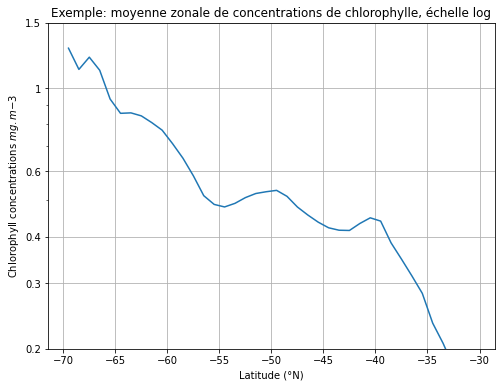

In [21]:
# Plot tout simple
fig,ax=plt.subplots(figsize=(8,6))
ax.plot(lat[:],1e3*chl_zonal_mean) #1e3 pour convertir en mg/m3
ax.grid()
ax.set_ylim([0.2,1.5]) #fixer les bornes inf et sup des axes
ax.set_yscale('log') # fixer une échelle logarithmique - pratique pour des concentrations
ax.set_yticks([0.2,0.3,0.4,0.6,1,1.5])
ax.set_yticklabels(['0.2','0.3','0.4','0.6','1','1.5'],fontsize=10) # fixer les labels sur les axes

ax.set_ylabel("Chlorophyll concentrations $mg.m{-3}$",fontsize=10)
ax.set_xlabel('Latitude (°N)',fontsize=10)
ax.set_title("Exemple: moyenne zonale de concentrations de chlorophylle, échelle log")
plt.show()

### Code pour le plot, en deux étapes

Cherche à tracer à droite, la carte de chlorophylle, et à gauche, sa moyenne zonale.

Pour cela, on va utiliser gridspec.
On définit une "grille" sur la figure (l'objet spec ci-dessous), qui est constitué de 2 colonnes (et une ligne).

spec = gridspec.GridSpec(ncols=2, nrows=1)

Et ensuite, on crée les objets ax un par un en les rajoutant sur la grille.

ax1 = fig.add_subplot(spec[0,0])

ax2 = fig.add_subplot(spec[0,1],projection=ccrs.PlateCarree())

ax1 sera le graphique: je n'ai pas besoin de projection. ax2 sera une carte: je dois définir une projection avec cartopy (ici, PlateCarree).

Une fois qu'on a fait ça, le reste est assez similaire aux codes de plots précédents: sur le graphique, on trace la moyenne zonale en fonction de la latitude; sur la carte, on trace les continents, les longitudes et latitudes, la chlorophylle (avec pcolormesh) et une colorbar.

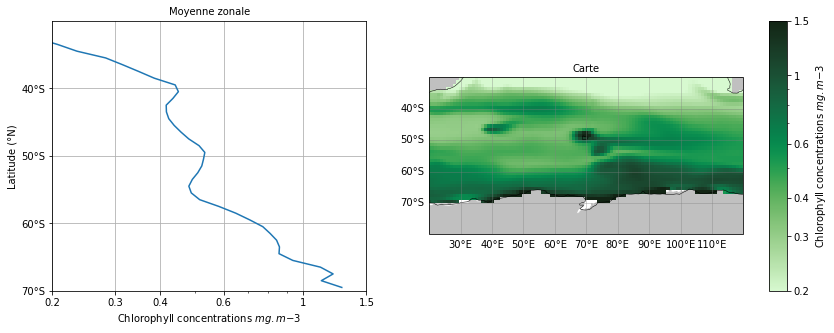

In [12]:
fig = plt.figure(figsize=(12,5))

# on crée deux matrices 2D de valeurs de longitude et latitude

X,Y=np.meshgrid(lon[ilon_min:ilon_max+1],lat)

# On crée une grille gridspec comme expliqué ci-dessus
spec = gridspec.GridSpec(ncols=2, nrows=1)

### Code du 1er plot: moyenne zonale
ax1 = fig.add_subplot(spec[0,0]) 
ax1.plot(1e3*chl_zonal_mean,lat[:]) #ici on inverse x, y par cohérence avec la carte
ax1.grid() # on rajoute une grille sous le graphique
ax1.set_xlim([0.2,1.5])
ax1.set_xscale('log') # on passe en échelle log pour les concentrations
ax1.set_xticks([0.2,0.3,0.4,0.6,1,1.5]) # on choisit les labels que l'on veut indiquer sur les axes
ax1.set_xticklabels(['0.2','0.3','0.4','0.6','1','1.5'],fontsize=10)

ax1.set_ylim([-70,-30]) # on définit les limites des latitudes

ax1.set_xlabel("Chlorophyll concentrations $mg.m{-3}$",fontsize=10) # on légende les axes
ax1.set_ylabel('Latitude (°N)',fontsize=10)
ax1.set_yticks([-70,-60,-50,-40])
ax1.set_yticklabels(['70°S','60°S','50°S','40°S'],fontsize=10)

### Code du 2e plot: carte
ax2 = fig.add_subplot(spec[0,1],projection=ccrs.PlateCarree())

# ajout du trait de côte
ax2.coastlines(resolution='110m',linewidth=0.5)
# ajout des continents
ax2.add_feature(cfeature.LAND, color='silver', zorder=1)
ax2.set_extent([20,120,-30,-80],ccrs.PlateCarree())
# légende des longitudes et latitudes
gl4 = ax2.gridlines(crs=ccrs.PlateCarree(),
                  linewidth=0.7, color='gray', alpha=0.5)

gl4.bottom_labels = True
gl4.left_labels = True  
gl4.xlocator = mticker.FixedLocator([20,30,40,50,60,70,80,90,100,110,120]) # on spécifie quelles longitudes on légende
gl4.ylocator = mticker.FixedLocator([-70,-60,-50,-40,-30]) # même chose pour les latitudes

gl4.xformatter = LONGITUDE_FORMATTER
gl4.yformatter = LATITUDE_FORMATTER
gl4.ylabel_style = {'size': 10, 'color': 'black'}
gl4.xlabel_style = {'size':10,'color': 'black'}
     
# ligne de code principale pour la carte    
im_proj=ax2.pcolormesh(X,Y,1e3*chl_NDJ_avg_region,norm=matplotlib.colors.LogNorm(vmin=0.2,vmax=1.5),cmap=cmocean.cm.algae,transform=ccrs.PlateCarree())

# on customise la colorbar
cbar_ax=fig.add_axes([0.9,0.15,0.02,0.75]) # localisation de la colorbar
cbar=fig.colorbar(im_proj,cax=cbar_ax,label='',orientation='vertical',ticks=[0.2,0.3,0.4,0.6,1,1.5])
cbar.ax.set_yticklabels(['0.2','0.3','0.4','0.6','1','1.5'],fontsize=10) # quels labels sont visibles sur la colorbar
cbar.set_label('Chlorophyll concentrations $mg.m{-3}$',fontsize=10) # et on légende la colorbar
    

ax1.set_title("Moyenne zonale",fontsize=10)
ax2.set_title("Carte",fontsize=10)

fig.subplots_adjust(bottom=0.15, top=0.9, left=0.07, right=0.87,wspace=0.2)

##### Quelques améliorations:
La figure ci-dessus n'est pas vraiment optimale: on voudrait que le graphique (à gauche) soit moins large, et que la carte occupe plus de place sur la figure, sachant qu'actuellement les deux objets tracés occupent la même place en largeur.

On peut encore utiliser gridspec pour cela: on va diviser la largeur en 6. Le premier graphe va occuper 1/6 de la largeur, et la carte les 5/6 restants.

En pratique, on va définir plus de colonnes qu'il n'en faut dans la grille (6 colonnes en tout). La première est occupée par le graphe, et les 5 suivantes par la carte.

*Tout ce qui change par rapport au plot précédent:*

spec = gridspec.GridSpec(ncols=6, nrows=1) # on définit 6 colonnes

ax1 = fig.add_subplot(spec[0,0:1]) # 1/6 de la largeur occupée par ax1

ax2 = fig.add_subplot(spec[0,1:],projection=ccrs.PlateCarree()) # le reste occupé par ax2


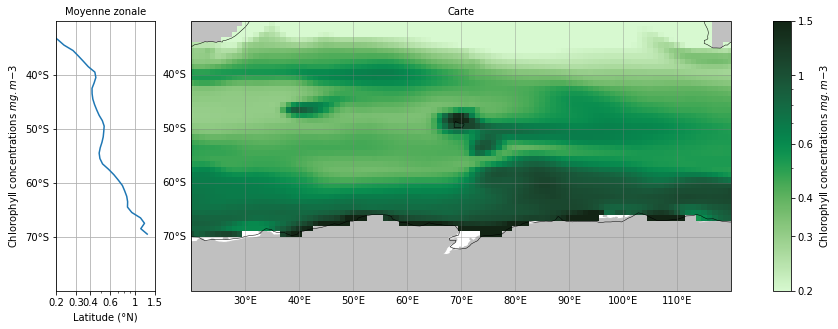

In [11]:
fig = plt.figure(figsize=(12,5))

X,Y=np.meshgrid(lon[ilon_min:ilon_max+1],lat)

spec = gridspec.GridSpec(ncols=6, nrows=1)

ax1 = fig.add_subplot(spec[0,0:1]) # row 0 1/6 width
ax1.plot(1e3*chl_zonal_mean,lat[:]) #ici on inverse x, y par cohérence avec la carte
ax1.grid()
ax1.set_xlim([0.2,1.5])
ax1.set_xscale('log')
ax1.set_xticks([0.2,0.3,0.4,0.6,1,1.5])
ax1.set_xticklabels(['0.2','0.3','0.4','0.6','1','1.5'],fontsize=10)

ax1.set_ylim([-70,-30])

ax1.set_xlabel("Chlorophyll concentrations $mg.m{-3}$",fontsize=10)
ax1.set_ylabel('Latitude (°N)',fontsize=10)
ax1.set_yticks([-70,-60,-50,-40])
ax1.set_yticklabels(['70°S','60°S','50°S','40°S'],fontsize=10)


ax2 = fig.add_subplot(spec[0,1:],projection=ccrs.PlateCarree())
ax2.sharey(ax1)

ax2.coastlines(resolution='110m',linewidth=0.5)

ax2.add_feature(cfeature.LAND, color='silver', zorder=1)
ax2.set_extent([20,120,-30,-80],ccrs.PlateCarree())

gl4 = ax2.gridlines(crs=ccrs.PlateCarree(),
                  linewidth=0.7, color='gray', alpha=0.5)

gl4.bottom_labels = True
gl4.left_labels = True  
gl4.xlocator = mticker.FixedLocator([20,30,40,50,60,70,80,90,100,110,120])
gl4.ylocator = mticker.FixedLocator([-70,-60,-50,-40,-30])

gl4.xformatter = LONGITUDE_FORMATTER
gl4.yformatter = LATITUDE_FORMATTER
gl4.ylabel_style = {'size': 10, 'color': 'black'}
gl4.xlabel_style = {'size':10,'color': 'black'}
               
im_proj=ax2.pcolormesh(X,Y,1e3*chl_NDJ_avg_region,norm=matplotlib.colors.LogNorm(vmin=0.2,vmax=1.5),cmap=cmocean.cm.algae,transform=ccrs.PlateCarree())

cbar_ax=fig.add_axes([0.9,0.15,0.02,0.75])
cbar=fig.colorbar(im_proj,cax=cbar_ax,label='',orientation='vertical',ticks=[0.2,0.3,0.4,0.6,1,1.5])
cbar.ax.set_yticklabels(['0.2','0.3','0.4','0.6','1','1.5'],fontsize=10)
cbar.set_label('Chlorophyll concentrations $mg.m{-3}$',fontsize=10)
    


ax1.set_title("Moyenne zonale",fontsize=10)
ax2.set_title("Carte",fontsize=10)

fig.subplots_adjust(bottom=0.15, top=0.9, left=0.07, right=0.87,wspace=0.2)